# **Problem 1: Minimum fuel optimal control**

We consider a linear dynamical system with state $x(t) \in \mathbb{R}^n$, $t = 0, \cdot\cdot\cdot, N$, and actuator or input signal $u(t) \in \mathbb{R}$, for $t = 0, \cdot\cdot\cdot, N-1$. The dynamics of the system is given by the linear recurrence

\begin{equation*}
x(t+1) = Ax(t) + bu(t), \quad t = 0, \cdot\cdot\cdot, N-1,
\end{equation*}

where $A \in \mathbb{R}^{n\times n}$ and $b \in \mathbb{R}^n$ are given. We assume that the initial state is zero, i.e., $x(0) = 0$. The minimum fuel optimal control problem is to choose the input $u(0), \cdot\cdot\cdot, u(N-1)$ so as to minimize the total fuel consumed, which is given by 

\begin{equation*}
F = \sum_{t=0}^{N-1} f(u(t))
\end{equation*}

subject to the constraint that $x(N) = x_{\text{des}}$, where $N$ is the (given) time horizon, and $x_{\text{des}} \in \mathbb{R}^n$ is the (given) final or target state. The function $f : \mathbb{R} \rightarrow \mathbb{R}$ is the fuel use map for the actuator, which gives the amount of fuel used as a function of the actuator signal amplitude. In this problem we use

\begin{equation*}
f(a) = \begin{cases}
|a| & \text{if } |a| \leq 1 \\
2|a| - 1 & \text{if } |a| > 1
\end{cases}
\end{equation*}

This means that fuel use is proportional to the absolute value of the actuator signal, for actuator signals between -1 and 1; for larger actuator signals the marginal fuel efficiency is half.

**Questions:**

a) Formulate the minimum fuel optimal control problem as an LP.

b) Solve the following instance of the problem:
\begin{equation*}
A = \begin{bmatrix} 1 & 1 \\ 0 & 0.95 \end{bmatrix},~ b = \begin{bmatrix} 0 \\ 0.1 \end{bmatrix},~ x(0) = (0, 0),~ x_{\text{des}} = (10, 0),~ N = 20.
\end{equation*}







We can interpret the system as a simple model of a vehicle moving in one dimension. The state dimension is $n = 2$, with $x_1(t)$ denoting the position of the vehicle at time $t$ and $x_2(t)$ giving its velocity. The initial state is $(0, 0)$, which corresponds to the vehicle at rest at position 0; the final state is $x_{\text{des}} = (10, 0)$, which corresponds to the vehicle being at rest at position 10. Roughly speaking, this means that the actuator input affects the velocity, which in turn affects the position. The coefficient $A_{22} = 0.95$ means that velocity decays by 5 in one sample period, if no actuator signal is applied. 

- Solve the problem using **cvxpy** in two ways and check that the solutions match:
  - By keeping operations $| \cdot |$, $\text{max}$, $\text{min}$ implicit and making **cvxpy** convert it to LP for you. 
  - By applying directly the LP formulation you obtained in point 1.

- Plot the input signal $u(t)$ for $t = 0,\cdots,19$, and the position and velocity (i.e., $x_1(t)$ and $x_2(t)$) for $t = 0,\cdots,20$.

# **Solution.**


In [14]:
# Import libraries:
%matplotlib inline
import numpy as np
np.set_printoptions(precision=2, suppress=True)
import matplotlib.pyplot as plt
from cvxpy import *

**a)**

We have specified $x(0) = 0$ and $x(N) = x_{\text{des}}$. From the linear recurrence, we can imply:
\begin{align*}
x(1) &= bu(0)\\ 
x(2) &= Abu(0) + bu(1)\\
x(3) &= A^2bu(0) + Abu(1) + bu(2)\\
       &\vdots\\
x(N) &= A^{N-1}bu(0) + A^{N-2}bu(1) + \cdots + Abu(N-1) + bu(N-1) = x_{\text{des}}
\end{align*}

Now, let's define the controllability matrix:

$$C = [A^{N-1}b \enspace A^{N-2}b \enspace \cdots \enspace Ab \enspace b]$$

Indeed, if we let $u^T = [u(0) \enspace \cdots \enspace u(N-1)]$, then our initial and target conditions for the problem become:

$$Cu = x_{\text{des}}$$

For the function $f(a)$ which represents the fuel use map for the actuator, we will try to formulate it to obtain an equivalent linear optimization. We can add new variables and inequalities in order to turn $f$ into a linear objective.

Since it is a convex piecewise function, so we can write $f$ with the expression as follows:

\begin{equation*}
f(a) = \begin{cases}
|a| & \text{if } |a| \leq 1 \\
2|a| - 1 & \text{if } |a| > 1
\end{cases} = \max\{|a|,~ 2|a|-1\}
\end{equation*}

And let $t = \max\{|a|,~ 2|a|-1\}$, then obtained the constraints:

$$\lvert a \rvert \leq t$$
$$2\lvert a\rvert-1 \leq t$$

Rewriting above, we have the inequalities:

$$-t \leq a \leq t$$
$$-\frac{t+1}{2} \leq a \leq \frac{t+1}{2}$$

Following this approach, we have added one new variable $t_{\text {i}}$ and four new inequality constraints for each $u(i)$.

That means we can now introduce a vector $t = [t_0, ..., t_{N-1}]$, one $t_i$ for each $u(i)$. 
Hence, the total fuel consumed, which is given by the function:
\begin{equation*}
F = \sum_{t=0}^{N-1} f(u(t))
\end{equation*}
now becomes:
\begin{equation*}
F = \sum_{i=0}^{N-1} t_{i}
\end{equation*}
Our linear program is then:

\begin{align*}
&\text{Minimize } & & \mathbf{1}^T t\\

&\text{subject to } & & -t \leq u \leq t\\
& & & -\frac{t+\mathbf{1}}{2} \leq u \leq \frac{t+\mathbf{1}}{2}\\
& & & Cu = x_{des}
\end{align*}



**b)**

**Problem Data:**

For this problem we are going to use the following given data:

- $N = 20$

- $n = 2$

- $A = \begin{bmatrix} 1 & 1 \\ 0 & 0.95 \end{bmatrix} \in \mathbb{R}^{2\times 2}$

- $b = \begin{bmatrix} 0 \\ 0.1 \end{bmatrix} \in \mathbb{R}^2$

- $x(0) = (0, 0) \in \mathbb{R}^2$

- $x_{\text{des}} = (10, 0) \in \mathbb{R}^2$


In [15]:
# Input the given data into Python:
N = 20
n = 2

A = np.array([[1, 1],[0, 0.95]], dtype=float)

b = np.array([0, 0.1], dtype=float).reshape(n,1)

xdes = np.array([10, 0], dtype=float)

**Way 1:** By keeping operations $| \cdot |$, $\text{max}$, $\text{min}$ implicit and making cvxpy convert it to LP for you. 

We are going to state the problem as a general optimization problem and let the CVXPY do the rest of the job.

\begin{align*}
&\underset{x, u}{\text{minimize}}

&& \sum_{t=0}^{N-1} \max(|u_t|,~ 2|u_t| - 1) \\
&\text{subject to}
&& x(0) = \mathbf{0}\\
&&& x(t+1) = Ax(t) + bu(t),~ \text{for}~ t=0, \ldots, N-1 \\

&&& x(N) = x_{\text{des}}
\end{align*}

In [16]:
# Define the constraints and objective function coefficients
X = Variable([n, N+1])
u = Variable([1, N])

obj = Minimize(sum(maximum(abs(u), 2*abs(u)-1)))

constr = [X[:, 0] == 0, X[:, 1:] == A@X[:,:N] + b@u, X[:, -1] == xdes]

# Solve the problem by using CVXPY
prob = Problem(obj, constr)
result = prob.solve()
print("Optimal value t*: ", result)
print("Optimal control input u*: ", u.value)

Optimal value t*:  15.911948890496248
Optimal control input u*:  [[ 3.23  1.    1.    1.    1.    1.    1.    0.    0.    0.    0.    0.
  -0.   -0.   -0.   -0.   -1.   -1.   -1.   -1.23]]


**Way 2:** By applying directly the LP formulation you obtained in part (a).

\begin{align*}
&\text{Minimize } & & \mathbf{1}^T t\\

&\text{subject to } & & -t \leq u \leq t\\
& & & -\frac{t+\mathbf{1}}{2} \leq u \leq \frac{t+\mathbf{1}}{2}\\
& & & Cu = x_{des}
\end{align*}
where $t = [t_0, ..., t_{N-1}]$, $u^T = [u(0) \enspace \cdots \enspace u(N-1)]$, $C = [A^{N-1}b \enspace A^{N-2}b \enspace \cdots \enspace Ab \enspace b]$

In [17]:
# Redefine the matrix A and vector b
A = np.array([[1, 1], [0, 0.95]], dtype=float)
b = np.array([0, 0.1], dtype=float).reshape(-1, 1)  # Reshape b to be a column vector

# Initialize C as an empty list
C = []

# Calculate and append the powers of A times b to C
for n in range(N, 0, -1):
    An = np.linalg.matrix_power(A, n - 1)
    C.append(np.dot(An, b))

# Stack the results horizontally to obtain the final C matrix
C = np.hstack(C)

# Define the constraints and objective function coefficients
U = Variable(N)
T = Variable(N)
objective = Minimize(np.ones(N).T @ T)
constraints = [
    -T <= U, 
    U <= T,
    -(T + np.ones(N))/2 <= U,
    U <= (T+np.ones(N))/2,
    C@U == xdes
]

# Solve the problem by using CVXPY
prob = Problem(objective, constraints)
result = prob.solve()
print("Optimal value t*: ", np.sum(T.value))
print("Optimal control input u*: ", U.value)

Optimal value t*:  15.911948842270723
Optimal control input u*:  [ 3.23  1.    1.    1.    1.    1.    1.    0.    0.    0.    0.    0.
 -0.   -0.   -0.   -0.   -1.   -1.   -1.   -1.23]


**_Plot the data_**

Text(0, 0.5, 'Actuator u(t)')

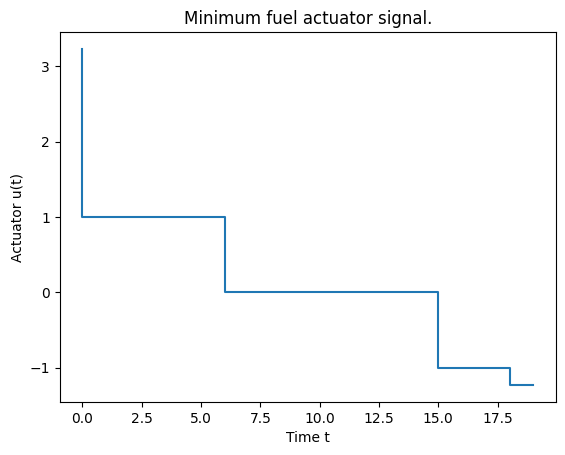

In [18]:
# Visualize the result

# Extract optimal u* from CVXPY solution
u_star = u.value.ravel() 
# Simulate system dynamics with optimal u*
A = np.array([[1, 1],[0, 0.95]], dtype=float)
b = np.array([0, 0.1])
n = 2

x = np.zeros((n, N+1))
for t in range(N):
    x[:,t+1] = A@x[:,t] + b*u_star[t]

# Plot the input signal at time t
plt.title('Minimum fuel actuator signal.')
plt.step(np.arange(N), np.ravel(u.value))
plt.xlabel('Time t')
plt.ylabel('Actuator u(t)')

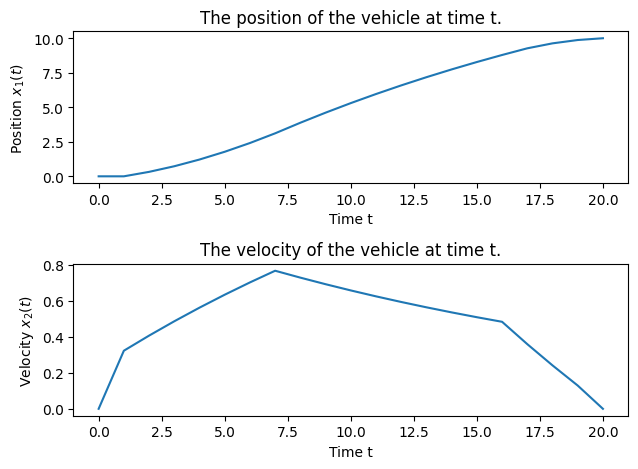

In [19]:
# Plot the position and velocity
plt.subplot(2,1,1)
plt.title('The position of the vehicle at time t.')
plt.plot(np.arange(N+1), x[0,:])
plt.ylabel('Position $x_1(t)$')
plt.xlabel('Time t')

plt.subplot(2,1,2)
plt.title('The velocity of the vehicle at time t.')
plt.plot(np.arange(N+1), x[1,:])  
plt.ylabel('Velocity $x_2(t)$')
plt.xlabel('Time t')

plt.tight_layout()
plt.show()